In [ ]:
# ============================================================
# TASK 8 — FAILURE SENSOR PREDICTOR
# NASA C-MAPSS FD001
# ============================================================

!pip -q install pandas numpy scikit-learn matplotlib seaborn joblib

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings("ignore")

print("✅ Environment ready!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", __import__("sklearn").__version__)

✅ Environment ready!
Pandas: 2.2.3
NumPy: 2.1.3
Scikit-learn: 1.6.1


In [ ]:
# ============================================================
# LOCATE DATASETS
# ============================================================

BASE_PATH = "/content"

TRAIN_FILE = os.path.join(BASE_PATH, "/content/train_FD001.txt")
TEST_FILE = os.path.join(BASE_PATH, "/content/test_FD001.txt")
RUL_FILE = os.path.join(BASE_PATH, "/content/RUL_FD001.txt")

required_files = {
    "Training": TRAIN_FILE,
    "Testing": TEST_FILE,
    "RUL": RUL_FILE
}

for name, path in required_files.items():
    print(f"{name}: {path}")
    print("Exists:", os.path.exists(path))
    print()

Training: /content/train_FD001.txt
Exists: True

Testing: /content/test_FD001.txt
Exists: True

RUL: /content/RUL_FD001.txt
Exists: True



In [ ]:
# ============================================================
# COLUMN DEFINITIONS
# ============================================================

columns = [
    "unit",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3"
]

sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

columns.extend(sensor_columns)

print("Number of columns:", len(columns))
print(columns)

Number of columns: 26
['unit', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [ ]:
# ============================================================
# LOAD TRAINING DATA
# ============================================================

train_df = pd.read_csv(
    TRAIN_FILE,
    sep=r"\s+",
    header=None,
    names=columns
)

print("Training shape:", train_df.shape)
train_df

Training shape: (20631, 26)


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [ ]:
train_df.head()

,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
train_df.tail()

,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


In [ ]:
# ============================================================
# LOAD TEST DATA + TRUE RUL
# ============================================================

test_df = pd.read_csv(
    TEST_FILE,
    sep=r"\s+",
    header=None,
    names=columns
)

rul_df = pd.read_csv(
    RUL_FILE,
    sep=r"\s+",
    header=None,
    names=["RUL"]
)

print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)

print("\nFirst test rows:")
display(test_df)

print("\nRUL values:")
display(rul_df)

Test shape: (13096, 26)
RUL shape: (100, 1)

First test rows:


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.0049,0.0000,100.0,518.67,643.24,1599.45,1415.79,14.62,...,520.69,2388.00,8213.28,8.4715,0.03,394,2388,100.0,38.65,23.1974
13092,100,195,-0.0011,-0.0001,100.0,518.67,643.22,1595.69,1422.05,14.62,...,521.05,2388.09,8210.85,8.4512,0.03,395,2388,100.0,38.57,23.2771
13093,100,196,-0.0006,-0.0003,100.0,518.67,643.44,1593.15,1406.82,14.62,...,521.18,2388.04,8217.24,8.4569,0.03,395,2388,100.0,38.62,23.2051
13094,100,197,-0.0038,0.0001,100.0,518.67,643.26,1594.99,1419.36,14.62,...,521.33,2388.08,8220.48,8.4711,0.03,395,2388,100.0,38.66,23.2699



RUL values:


,RUL
0,112
1,98
2,69
3,82
4,91
...,...
95,137
96,82
97,59
98,117


In [ ]:
# ============================================================
# DATA QUALITY INSPECTION
# ============================================================

print("TRAINING DATA")
print("=" * 60)

print("Shape:", train_df.shape)
print("Number of engines:", train_df["unit"].nunique())
print("Missing values:", train_df.isnull().sum().sum())

print("\nCycles per engine:")
print(train_df.groupby("unit")["cycle"].max().describe())

print("\nTEST DATA")
print("=" * 60)

print("Shape:", test_df.shape)
print("Number of engines:", test_df["unit"].nunique())
print("Missing values:", test_df.isnull().sum().sum())

TRAINING DATA
Shape: (20631, 26)
Number of engines: 100
Missing values: 0

Cycles per engine:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

TEST DATA
Shape: (13096, 26)
Number of engines: 100
Missing values: 0


In [ ]:
# ============================================================
# REMOVE CONSTANT / NEAR-CONSTANT FEATURES
# ============================================================

feature_candidates = [
    "setting_1",
    "setting_2",
    "setting_3"
] + sensor_columns

variances = train_df[feature_candidates].var()

constant_features = variances[variances == 0].index.tolist()

print("Constant features:")
print(constant_features)

model_features = [
    feature for feature in feature_candidates
    if feature not in constant_features
]

print("\nFeatures retained:", len(model_features))
print(model_features)

Constant features:
['setting_3', 'sensor_18', 'sensor_19']

Features retained: 21
['setting_1', 'setting_2', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_20', 'sensor_21']


In [ ]:
# ============================================================
# CALCULATE RUL
# ============================================================

max_cycles = (
    train_df
    .groupby("unit")["cycle"]
    .max()
    .rename("max_cycle")
)

train_df = train_df.merge(
    max_cycles,
    on="unit",
    how="left"
)

train_df["RUL"] = (
    train_df["max_cycle"] - train_df["cycle"]
)

train_df.drop(columns=["max_cycle"], inplace=True)

print(train_df[["unit", "cycle", "RUL"]].head(10))

   unit  cycle  RUL
0     1      1  191
1     1      2  190
2     1      3  189
3     1      4  188
4     1      5  187
5     1      6  186
6     1      7  185
7     1      8  184
8     1      9  183
9     1     10  182


In [ ]:
# ============================================================
# 24-CYCLE EARLY FAILURE LABEL
# ============================================================

EARLY_WARNING_HORIZON = 24

train_df["failure_soon"] = (
    train_df["RUL"] <= EARLY_WARNING_HORIZON
).astype(int)

print(
    train_df["failure_soon"]
    .value_counts()
    .rename({0: "Normal", 1: "Failure Soon"})
)

print("\nClass proportions:")
print(
    train_df["failure_soon"]
    .value_counts(normalize=True)
)

failure_soon
Normal          18131
Failure Soon     2500
Name: count, dtype: int64

Class proportions:
failure_soon
0    0.878823
1    0.121177
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# ROLLING-WINDOW FEATURE ENGINEERING
# ============================================================

ROLLING_WINDOW = 12

def create_rolling_features(df, feature_columns, window=12):

    result = df.copy()

    result = result.sort_values(
        ["unit", "cycle"]
    ).reset_index(drop=True)

    for feature in feature_columns:

        grouped = result.groupby("unit")[feature]

        result[f"{feature}_rolling_mean"] = (
            grouped
            .rolling(window, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        result[f"{feature}_rolling_std"] = (
            grouped
            .rolling(window, min_periods=2)
            .std()
            .reset_index(level=0, drop=True)
            .fillna(0)
        )

        result[f"{feature}_diff"] = (
            grouped
            .diff()
            .fillna(0)
        )

    return result


train_features_df = create_rolling_features(
    train_df,
    model_features,
    ROLLING_WINDOW
)

print("Original features:", len(model_features))
print("Final feature count:",
      len([
          c for c in train_features_df.columns
          if c not in [
              "unit",
              "cycle",
              "RUL",
              "failure_soon"
          ]
      ])
)

Original features: 21
Final feature count: 87


In [ ]:
# ============================================================
# CLEAN FEATURE DATA
# ============================================================

train_features_df = train_features_df.replace(
    [np.inf, -np.inf],
    np.nan
)

train_features_df = train_features_df.dropna()

print("Final training shape:", train_features_df.shape)
print("Missing values:", train_features_df.isnull().sum().sum())

Final training shape: (20631, 91)
Missing values: 0


In [ ]:
# ============================================================
# PREPARE MODEL INPUT
# ============================================================

EXCLUDE_COLUMNS = [
    "unit",
    "cycle",
    "RUL",
    "failure_soon"
]

FEATURE_COLUMNS = [
    column
    for column in train_features_df.columns
    if column not in EXCLUDE_COLUMNS
]

X = train_features_df[FEATURE_COLUMNS]
y = train_features_df["failure_soon"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (20631, 87)
y shape: (20631,)

Target distribution:
failure_soon
0    18131
1     2500
Name: count, dtype: int64


In [ ]:
# ============================================================
# ENGINE-AWARE TRAIN / VALIDATION SPLIT
# ============================================================

units = sorted(train_features_df["unit"].unique())

split_index = int(len(units) * 0.8)

train_units = units[:split_index]
validation_units = units[split_index:]

train_part = train_features_df[
    train_features_df["unit"].isin(train_units)
]

validation_part = train_features_df[
    train_features_df["unit"].isin(validation_units)
]

X_train = train_part[FEATURE_COLUMNS]
y_train = train_part["failure_soon"]

X_val = validation_part[FEATURE_COLUMNS]
y_val = validation_part["failure_soon"]

print("Training engines:", len(train_units))
print("Validation engines:", len(validation_units))

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))

Training engines: 80
Validation engines: 20

Training samples: 16138
Validation samples: 4493


In [ ]:
# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Features scaled.")

Features scaled.


In [ ]:
# ============================================================
# RANDOM FOREST FAILURE PREDICTOR
# ============================================================

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_scaled,
    y_train
)

print("Model trained!")

Model trained!


In [ ]:
# ============================================================
# EVALUATION
# ============================================================

y_val_pred = model.predict(X_val_scaled)

precision = precision_score(
    y_val,
    y_val_pred,
    zero_division=0
)

recall = recall_score(
    y_val,
    y_val_pred,
    zero_division=0
)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Normal", "Failure Soon"],
        zero_division=0
    )
)

Precision: 0.8084
Recall: 0.886

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98      3993
Failure Soon       0.81      0.89      0.85       500

    accuracy                           0.96      4493
   macro avg       0.90      0.93      0.91      4493
weighted avg       0.97      0.96      0.96      4493



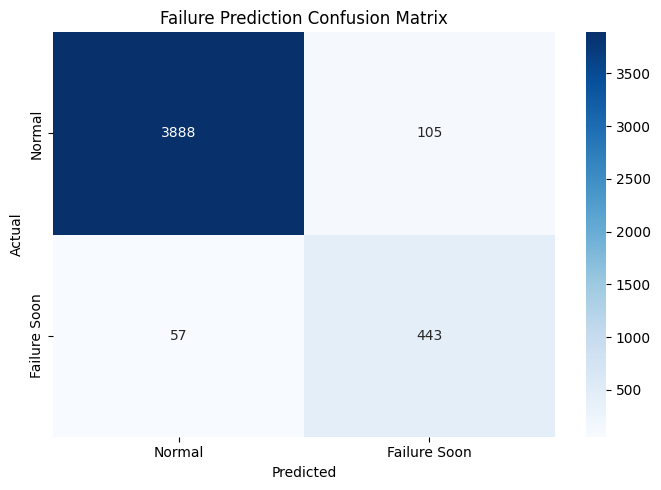

In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_val,
    y_val_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Failure Soon"],
    yticklabels=["Normal", "Failure Soon"]
)

plt.title("Failure Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.show()

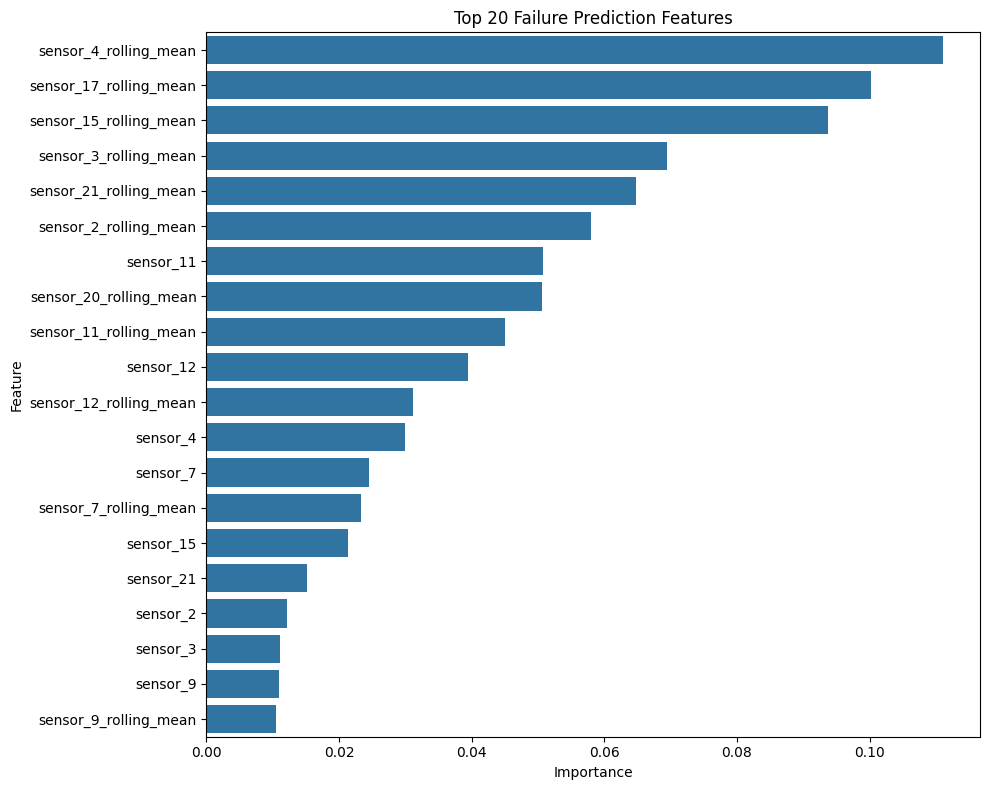

In [ ]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title("Top 20 Failure Prediction Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

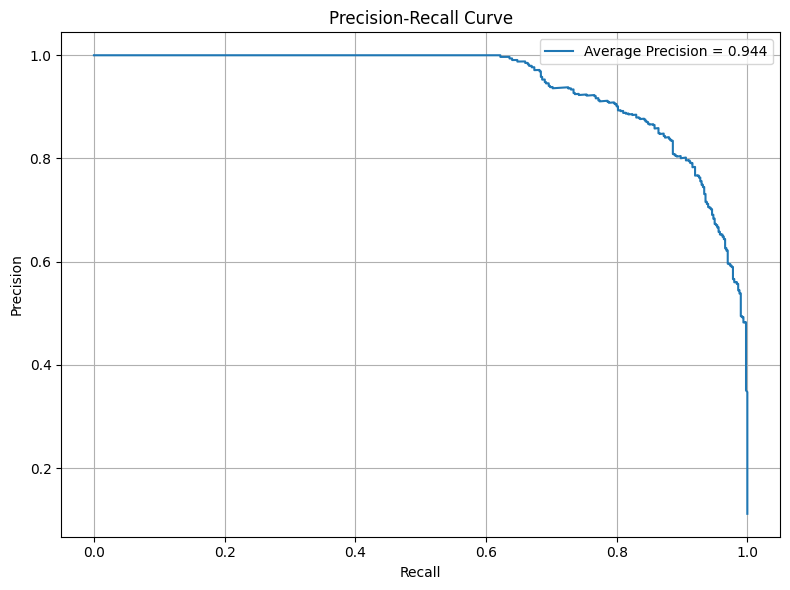

In [ ]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

y_val_probability = model.predict_proba(
    X_val_scaled
)[:, 1]

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_val,
    y_val_probability
)

average_precision = average_precision_score(
    y_val,
    y_val_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Average Precision = {average_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SAVE MODEL ARTIFACTS
# ============================================================

MODEL_DIR = "/content/failure_sensor_model"

os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(
    model,
    os.path.join(MODEL_DIR, "failure_predictor.joblib")
)

joblib.dump(
    scaler,
    os.path.join(MODEL_DIR, "feature_scaler.joblib")
)

joblib.dump(
    FEATURE_COLUMNS,
    os.path.join(MODEL_DIR, "feature_columns.joblib")
)

print("Model artifacts saved:")
print(MODEL_DIR)

print("\nFiles:")
for file in os.listdir(MODEL_DIR):
    print(" -", file)

Model artifacts saved:
/content/failure_sensor_model

Files:
 - failure_predictor.joblib
 - feature_scaler.joblib
 - feature_columns.joblib


In [ ]:
# ============================================================
# SAVE EVALUATION RESULTS
# ============================================================

import json
from sklearn.metrics import f1_score

f1 = f1_score(
    y_val,
    y_val_pred,
    zero_division=0
)

evaluation_report = {
    "dataset": "NASA C-MAPSS FD001",
    "model": "Random Forest Classifier",
    "rolling_window_cycles": ROLLING_WINDOW,
    "early_warning_horizon_cycles": EARLY_WARNING_HORIZON,
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "training_engines": len(train_units),
    "validation_engines": len(validation_units),
    "training_samples": len(X_train),
    "validation_samples": len(X_val)
}

REPORT_DIR = "/content/failure_sensor_model"
REPORT_PATH = os.path.join(
    REPORT_DIR,
    "evaluation_report.json"
)

with open(REPORT_PATH, "w") as f:
    json.dump(
        evaluation_report,
        f,
        indent=4
    )

print(json.dumps(
    evaluation_report,
    indent=4
))

{
    "dataset": "NASA C-MAPSS FD001",
    "model": "Random Forest Classifier",
    "rolling_window_cycles": 12,
    "early_warning_horizon_cycles": 24,
    "precision": 0.8083941605839416,
    "recall": 0.886,
    "f1_score": 0.8454198473282443,
    "training_engines": 80,
    "validation_engines": 20,
    "training_samples": 16138,
    "validation_samples": 4493
}


In [ ]:
# ============================================================
# PREPARE TEST RUL
# ============================================================

# Maximum observed cycle for each test engine
test_max_cycles = (
    test_df
    .groupby("unit")["cycle"]
    .max()
    .rename("max_cycle")
)

test_df = test_df.merge(
    test_max_cycles,
    on="unit",
    how="left"
)

# RUL at the end of each test trajectory
test_rul_values = rul_df["RUL"].values

# Make sure number of RUL values matches number of test engines
print("Number of test engines:", test_df["unit"].nunique())
print("Number of RUL values:", len(test_rul_values))

assert test_df["unit"].nunique() == len(test_rul_values), \
    "Number of test engines and RUL values do not match."

# Map final RUL to each engine
engine_rul_map = {
    unit: rul
    for unit, rul in zip(
        sorted(test_df["unit"].unique()),
        test_rul_values
    )
}

test_df["final_RUL"] = test_df["unit"].map(engine_rul_map)

# RUL for every test observation
test_df["RUL"] = (
    test_df["final_RUL"]
    + test_df["max_cycle"]
    - test_df["cycle"]
)

# 24-cycle early-warning target
test_df["failure_soon"] = (
    test_df["RUL"] <= EARLY_WARNING_HORIZON
).astype(int)

test_df.drop(
    columns=["max_cycle", "final_RUL"],
    inplace=True
)

print("\nTest data prepared.")
display(
    test_df[
        ["unit", "cycle", "RUL", "failure_soon"]
    ].head(10)
)

Number of test engines: 100
Number of RUL values: 100

Test data prepared.


,unit,cycle,RUL,failure_soon
0,1,1,142,0
1,1,2,141,0
2,1,3,140,0
3,1,4,139,0
4,1,5,138,0
5,1,6,137,0
6,1,7,136,0
7,1,8,135,0
8,1,9,134,0
9,1,10,133,0


In [ ]:
# ============================================================
# TEST FEATURE ENGINEERING
# ============================================================

test_features_df = create_rolling_features(
    test_df,
    model_features,
    ROLLING_WINDOW
)

test_features_df = test_features_df.replace(
    [np.inf, -np.inf],
    np.nan
)

test_features_df = test_features_df.dropna()

print("Test feature shape:", test_features_df.shape)
print("Missing values:", test_features_df.isnull().sum().sum())

Test feature shape: (13096, 91)
Missing values: 0


In [ ]:
# ============================================================
# PREPARE TEST INPUT
# ============================================================

X_test = test_features_df[FEATURE_COLUMNS]
y_test = test_features_df["failure_soon"]

# IMPORTANT:
# Do NOT fit the scaler again.
# Use the scaler fitted on training data.

X_test_scaled = scaler.transform(X_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTest target distribution:")
print(
    y_test
    .value_counts()
    .rename({
        0: "Normal",
        1: "Failure Soon"
    })
)

X_test shape: (13096, 87)
y_test shape: (13096,)

Test target distribution:
failure_soon
Normal          12897
Failure Soon      199
Name: count, dtype: int64


In [ ]:
# ============================================================
# FINAL TEST PREDICTIONS
# ============================================================

y_test_pred = model.predict(
    X_test_scaled
)

y_test_probability = model.predict_proba(
    X_test_scaled
)[:, 1]

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

print("=" * 60)
print("FINAL TEST-SET PERFORMANCE")
print("=" * 60)

print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "Normal",
            "Failure Soon"
        ],
        zero_division=0
    )
)

FINAL TEST-SET PERFORMANCE
Precision : 0.6946
Recall    : 0.7085

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     12897
Failure Soon       0.69      0.71      0.70       199

    accuracy                           0.99     13096
   macro avg       0.85      0.85      0.85     13096
weighted avg       0.99      0.99      0.99     13096



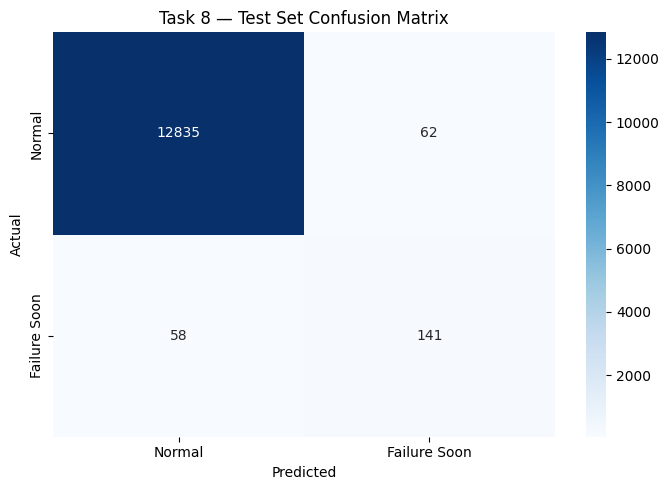

In [ ]:
# ============================================================
# TEST CONFUSION MATRIX
# ============================================================

test_cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Normal",
        "Failure Soon"
    ],
    yticklabels=[
        "Normal",
        "Failure Soon"
    ]
)

plt.title(
    "Task 8 — Test Set Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PREDICTION OUTPUT
# ============================================================

test_predictions = test_features_df[
    ["unit", "cycle", "RUL"]
].copy()

test_predictions["actual_failure_soon"] = y_test.values
test_predictions["predicted_failure_soon"] = y_test_pred
test_predictions["failure_probability"] = y_test_probability

test_predictions["prediction_correct"] = (
    test_predictions["actual_failure_soon"]
    ==
    test_predictions["predicted_failure_soon"]
)

print("Prediction output:")
display(test_predictions.head(15))

Prediction output:


,unit,cycle,RUL,actual_failure_soon,predicted_failure_soon,failure_probability,prediction_correct
0,1,1,142,0,0,0.037956,True
1,1,2,141,0,0,0.014491,True
2,1,3,140,0,0,0.014491,True
3,1,4,139,0,0,0.004680,True
4,1,5,138,0,0,0.000000,True
5,1,6,137,0,0,0.000000,True
6,1,7,136,0,0,0.000000,True
7,1,8,135,0,0,0.000000,True
8,1,9,134,0,0,0.000000,True
9,1,10,133,0,0,0.000000,True


In [ ]:
# ============================================================
# SAVE PREDICTIONS
# ============================================================

OUTPUT_DIR = "/content/failure_sensor_model"

os.makedirs(OUTPUT_DIR, exist_ok=True)

PREDICTION_PATH = os.path.join(
    OUTPUT_DIR,
    "FD001_test_predictions.csv"
)

test_predictions.to_csv(
    PREDICTION_PATH,
    index=False
)

print("Predictions saved:")
print(PREDICTION_PATH)

Predictions saved:
/content/failure_sensor_model/FD001_test_predictions.csv


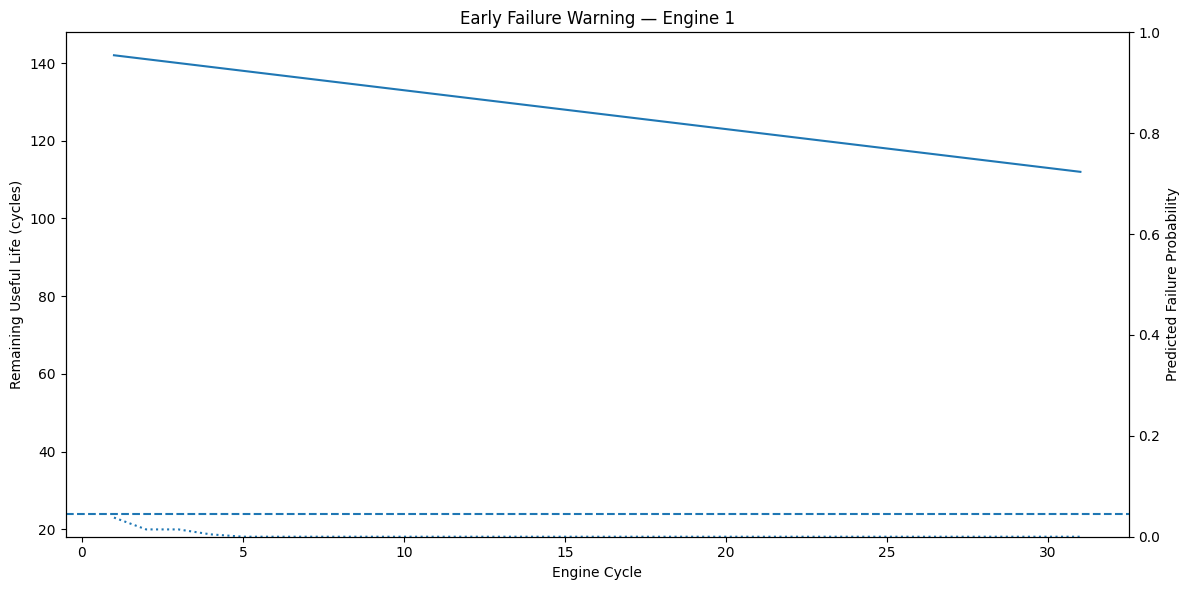

In [ ]:
# ============================================================
# EARLY WARNING TIMELINE
# ============================================================

engine_id = 1

engine_results = test_predictions[
    test_predictions["unit"] == engine_id
].sort_values("cycle")

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    engine_results["cycle"],
    engine_results["RUL"],
    label="Actual RUL"
)

ax1.axhline(
    EARLY_WARNING_HORIZON,
    linestyle="--",
    label="24-Cycle Warning Threshold"
)

ax1.set_xlabel("Engine Cycle")
ax1.set_ylabel("Remaining Useful Life (cycles)")

ax2 = ax1.twinx()

ax2.plot(
    engine_results["cycle"],
    engine_results["failure_probability"],
    linestyle=":",
    label="Failure Probability"
)

ax2.set_ylabel("Predicted Failure Probability")
ax2.set_ylim(0, 1)

plt.title(
    f"Early Failure Warning — Engine {engine_id}"
)

fig.tight_layout()
plt.show()

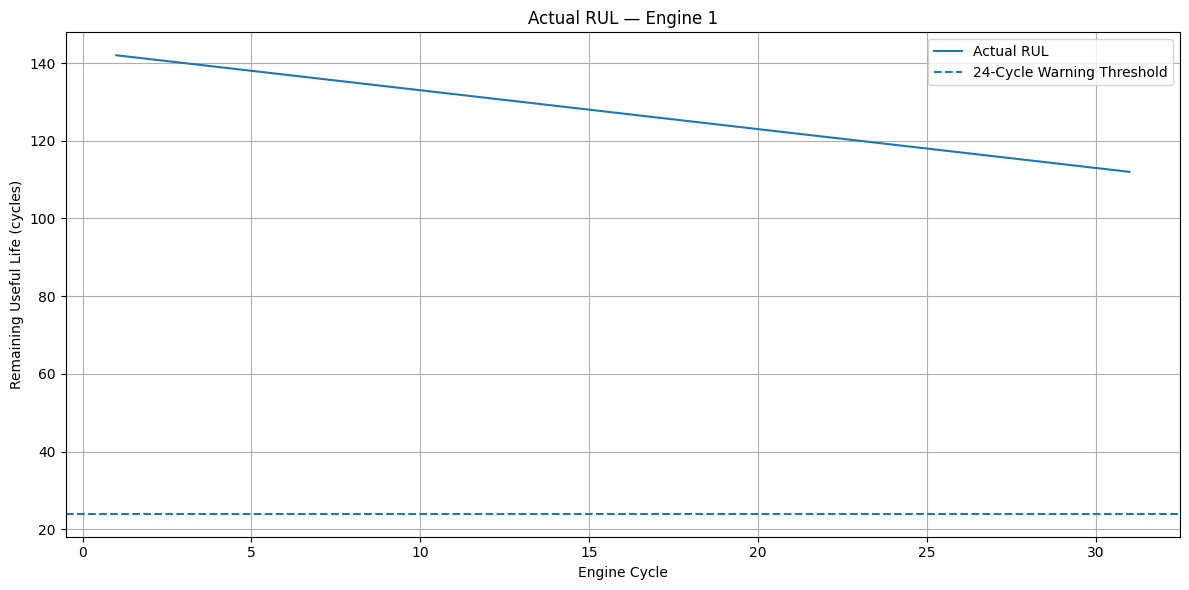

Saved: /content/failure_sensor_model/figures/early_warning_timeline.png


In [ ]:
# ============================================================
# SAVE TIMELINE CHART
# ============================================================

FIGURE_DIR = "/content/failure_sensor_model/figures"

os.makedirs(FIGURE_DIR, exist_ok=True)

plt.figure(figsize=(12, 6))

plt.plot(
    engine_results["cycle"],
    engine_results["RUL"],
    label="Actual RUL"
)

plt.axhline(
    EARLY_WARNING_HORIZON,
    linestyle="--",
    label="24-Cycle Warning Threshold"
)

plt.xlabel("Engine Cycle")
plt.ylabel("Remaining Useful Life (cycles)")
plt.title(
    f"Actual RUL — Engine {engine_id}"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

timeline_path = os.path.join(
    FIGURE_DIR,
    "early_warning_timeline.png"
)

plt.savefig(
    timeline_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", timeline_path)

In [ ]:
# ============================================================
# FINAL EVALUATION REPORT
# ============================================================

from sklearn.metrics import f1_score

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

final_report = {
    "project": "Failure Sensor Predictor",
    "task": "Task 8",
    "dataset": "NASA C-MAPSS FD001",
    "model": "Random Forest Classifier",
    "rolling_window_cycles": ROLLING_WINDOW,
    "early_warning_horizon_cycles": EARLY_WARNING_HORIZON,
    "training_engines": int(len(train_units)),
    "validation_engines": int(len(validation_units)),
    "test_engines": int(test_df["unit"].nunique()),
    "training_samples": int(len(X_train)),
    "validation_samples": int(len(X_val)),
    "test_samples": int(len(X_test)),
    "precision": float(test_precision),
    "recall": float(test_recall),
    "f1_score": float(test_f1)
}

FINAL_REPORT_PATH = os.path.join(
    OUTPUT_DIR,
    "final_evaluation_report.json"
)

with open(FINAL_REPORT_PATH, "w") as f:
    json.dump(
        final_report,
        f,
        indent=4
    )

print(json.dumps(
    final_report,
    indent=4
))

{
    "project": "Failure Sensor Predictor",
    "task": "Task 8",
    "dataset": "NASA C-MAPSS FD001",
    "model": "Random Forest Classifier",
    "rolling_window_cycles": 12,
    "early_warning_horizon_cycles": 24,
    "training_engines": 80,
    "validation_engines": 20,
    "test_engines": 100,
    "training_samples": 16138,
    "validation_samples": 4493,
    "test_samples": 13096,
    "precision": 0.6945812807881774,
    "recall": 0.7085427135678392,
    "f1_score": 0.7014925373134329
}


In [ ]:
# ============================================================
# SAVE COMPLETE MODEL PACKAGE
# ============================================================

MODEL_PACKAGE = {
    "model": model,
    "scaler": scaler,
    "feature_columns": FEATURE_COLUMNS,
    "model_features": model_features,
    "rolling_window": ROLLING_WINDOW,
    "early_warning_horizon": EARLY_WARNING_HORIZON
}

MODEL_PACKAGE_PATH = os.path.join(
    OUTPUT_DIR,
    "failure_sensor_predictor_package.joblib"
)

joblib.dump(
    MODEL_PACKAGE,
    MODEL_PACKAGE_PATH
)

print("Complete model package saved:")
print(MODEL_PACKAGE_PATH)

Complete model package saved:
/content/failure_sensor_model/failure_sensor_predictor_package.joblib


In [ ]:
# ============================================================
# INFERENCE FUNCTION
# ============================================================

def predict_failure_risk(
    new_sensor_data,
    model_package
):
    """
    Predict approaching failure risk from
    C-MAPSS-style sensor telemetry.

    Parameters
    ----------
    new_sensor_data : pandas.DataFrame
        Sensor telemetry containing unit, cycle,
        operational settings and sensor columns.

    model_package : dict
        Saved model, scaler and feature configuration.

    Returns
    -------
    pandas.DataFrame
        Failure probabilities and predictions.
    """

    model = model_package["model"]
    scaler = model_package["scaler"]
    feature_columns = model_package["feature_columns"]
    model_features = model_package["model_features"]
    rolling_window = model_package["rolling_window"]

    processed = create_rolling_features(
        new_sensor_data,
        model_features,
        rolling_window
    )

    processed = processed.replace(
        [np.inf, -np.inf],
        np.nan
    )

    processed = processed.dropna()

    X_new = processed[feature_columns]

    X_new_scaled = scaler.transform(X_new)

    probability = model.predict_proba(
        X_new_scaled
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    results = processed[
        ["unit", "cycle"]
    ].copy()

    results["failure_probability"] = probability
    results["failure_prediction"] = prediction

    return results

In [ ]:
# ============================================================
# INFERENCE TEST
# ============================================================

loaded_package = joblib.load(
    MODEL_PACKAGE_PATH
)

inference_results = predict_failure_risk(
    test_df.copy(),
    loaded_package
)

display(
    inference_results.head(20)
)

,unit,cycle,failure_probability,failure_prediction
0,1,1,0.037956,0
1,1,2,0.014491,0
2,1,3,0.014491,0
3,1,4,0.004680,0
4,1,5,0.000000,0
5,1,6,0.000000,0
6,1,7,0.000000,0
7,1,8,0.000000,0
8,1,9,0.000000,0
9,1,10,0.000000,0


In [ ]:
# ============================================================
# FINAL PROJECT STRUCTURE
# ============================================================

PROJECT_ROOT = "/content/AIML_8_FailureSensorPredictor_byte"

folders = [
    "data",
    "notebooks",
    "src",
    "models",
    "outputs",
    "outputs/figures",
    "outputs/predictions",
    "reports"
]

for folder in folders:
    os.makedirs(
        os.path.join(PROJECT_ROOT, folder),
        exist_ok=True
    )

print("Project structure created.")

for root, dirs, files in os.walk(PROJECT_ROOT):
    level = root.replace(PROJECT_ROOT, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

Project structure created.
AIML_8_FailureSensorPredictor_byte/
    notebooks/
    outputs/
        figures/
        predictions/
    data/
    src/
    reports/
    models/


In [ ]:
# ============================================================
# COPY FINAL ARTIFACTS
# ============================================================

import shutil

# Models
shutil.copy2(
    MODEL_PACKAGE_PATH,
    os.path.join(
        PROJECT_ROOT,
        "models",
        "failure_sensor_predictor_package.joblib"
    )
)

# Predictions
shutil.copy2(
    PREDICTION_PATH,
    os.path.join(
        PROJECT_ROOT,
        "outputs",
        "predictions",
        "FD001_test_predictions.csv"
    )
)

# Evaluation report
shutil.copy2(
    FINAL_REPORT_PATH,
    os.path.join(
        PROJECT_ROOT,
        "reports",
        "final_evaluation_report.json"
    )
)

# Figure
if os.path.exists(timeline_path):
    shutil.copy2(
        timeline_path,
        os.path.join(
            PROJECT_ROOT,
            "outputs",
            "figures",
            "early_warning_timeline.png"
        )
    )

print("Artifacts copied into final project.")

Artifacts copied into final project.


In [ ]:
# ============================================================
# REQUIREMENTS.TXT
# ============================================================

requirements = """pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
"""

requirements_path = os.path.join(
    PROJECT_ROOT,
    "requirements.txt"
)

with open(requirements_path, "w") as f:
    f.write(requirements)

print(requirements)

pandas
numpy
scikit-learn
matplotlib
seaborn
joblib



In [ ]:
# ============================================================
# README.MD
# ============================================================

readme = f"""
# Failure Sensor Predictor — Task 8

## Overview

An AI/ML predictive-maintenance system built using NASA C-MAPSS
FD001 turbofan engine degradation data.

The system uses multivariate engine telemetry to identify whether
an engine is approaching failure within a defined early-warning
horizon.

## Pipeline

Raw C-MAPSS telemetry
→ preprocessing
→ RUL calculation
→ 24-cycle early-warning labeling
→ rolling-window feature engineering
→ feature scaling
→ Random Forest classification
→ precision/recall evaluation
→ failure-risk inference

## Dataset

NASA C-MAPSS FD001.

The raw dataset is not redistributed in this repository.
Users should obtain it from the official NASA dataset source.

## Model

Random Forest Classifier

### Feature Engineering

- Rolling mean
- Rolling standard deviation
- First-order sensor differences
- Operational settings
- Sensor measurements

Rolling window: {ROLLING_WINDOW} cycles

Early-warning horizon: {EARLY_WARNING_HORIZON} cycles

## Final Test Results

| Metric | Score |
|---|---:|
| Precision | {test_precision:.4f} |
| Recall | {test_recall:.4f} |
| F1 Score | {test_f1:.4f} |

## Project Structure

AIML_8_FailureSensorPredictor_byte/
├── data/
├── notebooks/
├── src/
├── models/
├── outputs/
│   ├── figures/
│   └── predictions/
├── reports/
├── requirements.txt
├── README.md
└── .gitignore

## Reproducibility

1. Obtain the NASA C-MAPSS dataset.
2. Place the FD001 files in the data directory.
3. Install the dependencies.
4. Run the training notebook.
5. Evaluate the model.
6. Use the saved model package for inference.

## Important Note

C-MAPSS records engine operating cycles rather than explicit
clock-hour timestamps. Therefore, the early-warning horizon is
reported in cycles rather than assuming that one cycle equals
one hour.
"""

README_PATH = os.path.join(
    PROJECT_ROOT,
    "README.md"
)

with open(README_PATH, "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md created successfully!")
print("Location:")
print(README_PATH)

README.md created successfully!
Location:
/content/AIML_8_FailureSensorPredictor_byte/README.md


In [ ]:
# ============================================================
# GITIGNORE
# ============================================================

gitignore = """# Python
__pycache__/
*.pyc

# Jupyter
.ipynb_checkpoints/

# Raw datasets
data/*.txt
data/*.csv
data/*.zip

# Temporary files
*.tmp
.DS_Store
"""

gitignore_path = os.path.join(
    PROJECT_ROOT,
    ".gitignore"
)

with open(gitignore_path, "w", encoding="utf-8") as f:
    f.write(gitignore)

print(".gitignore created!")
print(gitignore_path)

.gitignore created!
/content/AIML_8_FailureSensorPredictor_byte/.gitignore


In [ ]:
# ============================================================
# FINAL PROJECT AUDIT
# ============================================================

print("=" * 70)
print("FINAL TASK 8 PROJECT AUDIT")
print("=" * 70)

for root, dirs, files in os.walk(PROJECT_ROOT):

    relative_root = os.path.relpath(
        root,
        PROJECT_ROOT
    )

    for file in files:

        file_path = os.path.join(root, file)

        size_kb = os.path.getsize(file_path) / 1024

        print(
            f"{os.path.join(relative_root, file):70s}"
            f"{size_kb:10.1f} KB"
        )

print("\nTask 8 artifact generation complete!")

FINAL TASK 8 PROJECT AUDIT
./README.md                                                                  1.8 KB
./requirements.txt                                                           0.1 KB
./.gitignore                                                                 0.1 KB
outputs/figures/early_warning_timeline.png                                 133.1 KB
outputs/predictions/FD001_test_predictions.csv                             324.0 KB
reports/final_evaluation_report.json                                         0.5 KB
models/failure_sensor_predictor_package.joblib                           10058.3 KB

Task 8 artifact generation complete!


In [ ]:
# ============================================================
# QUALITY PASS 1 — THRESHOLD ANALYSIS
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    val_pred_threshold = (
        y_val_probability >= threshold
    ).astype(int)

    p = precision_score(
        y_val,
        val_pred_threshold,
        zero_division=0
    )

    r = recall_score(
        y_val,
        val_pred_threshold,
        zero_division=0
    )

    f1_value = f1_score(
        y_val,
        val_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": p,
        "recall": r,
        "f1": f1_value
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.style.format({
        "threshold": "{:.2f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}"
    })
)

,threshold,precision,recall,f1
0,0.10,0.566,0.980,0.717
1,0.15,0.602,0.970,0.743
2,0.20,0.636,0.966,0.767
3,0.25,0.670,0.952,0.787
4,0.30,0.692,0.946,0.799
5,0.35,0.717,0.936,0.812
6,0.40,0.750,0.930,0.830
7,0.45,0.788,0.916,0.847
8,0.50,0.808,0.886,0.845
9,0.55,0.847,0.872,0.859


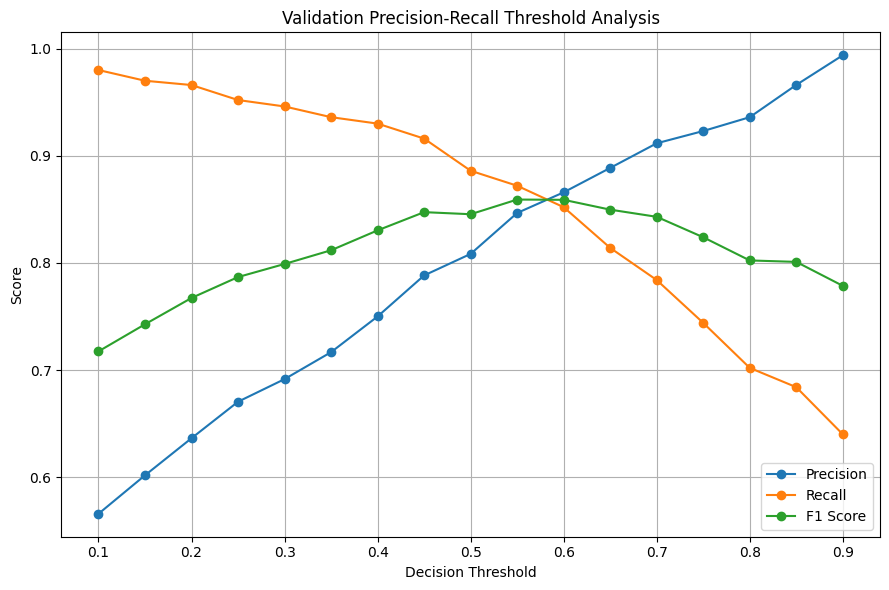

In [ ]:
# ============================================================
# QUALITY PASS 2 — VISUALIZE PRECISION/RECALL TRADE-OFF
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Validation Precision-Recall Threshold Analysis")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# QUALITY PASS 3 — LOCK VALIDATION THRESHOLD
# ============================================================

FINAL_THRESHOLD = 0.55

print("Final decision threshold:", FINAL_THRESHOLD)
print("Threshold selected using validation data only.")

Final decision threshold: 0.55
Threshold selected using validation data only.


In [ ]:
# ============================================================
# QUALITY PASS 4 — FINAL TEST EVALUATION
# ============================================================

# Apply the LOCKED threshold to the test probabilities
y_test_pred_tuned = (
    y_test_probability >= FINAL_THRESHOLD
).astype(int)

final_precision = precision_score(
    y_test,
    y_test_pred_tuned,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_test_pred_tuned,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_test_pred_tuned,
    zero_division=0
)

print("=" * 65)
print("FINAL LOCKED TEST-SET PERFORMANCE")
print("=" * 65)

print(f"Decision Threshold : {FINAL_THRESHOLD:.2f}")
print(f"Precision          : {final_precision:.4f}")
print(f"Recall             : {final_recall:.4f}")
print(f"F1 Score           : {final_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_tuned,
        target_names=[
            "Normal",
            "Failure Soon"
        ],
        zero_division=0
    )
)

FINAL LOCKED TEST-SET PERFORMANCE
Decision Threshold : 0.55
Precision          : 0.7386
Recall             : 0.6533
F1 Score           : 0.6933

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     12897
Failure Soon       0.74      0.65      0.69       199

    accuracy                           0.99     13096
   macro avg       0.87      0.82      0.84     13096
weighted avg       0.99      0.99      0.99     13096



In [ ]:
# ============================================================
# QUALITY PASS 5 — BEFORE vs TUNED
# ============================================================

comparison = pd.DataFrame({
    "Version": [
        "Default threshold (0.50)",
        "Tuned threshold (0.55)"
    ],
    "Threshold": [
        0.50,
        FINAL_THRESHOLD
    ],
    "Precision": [
        test_precision,
        final_precision
    ],
    "Recall": [
        test_recall,
        final_recall
    ],
    "F1": [
        f1_score(y_test, y_test_pred, zero_division=0),
        final_f1
    ]
})

display(
    comparison.style.format({
        "Threshold": "{:.2f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

,Version,Threshold,Precision,Recall,F1
0,Default threshold (0.50),0.50,0.6946,0.7085,0.7015
1,Tuned threshold (0.55),0.55,0.7386,0.6533,0.6933


In [ ]:
# ============================================================
# QUALITY PASS 6 — ERROR ANALYSIS
# ============================================================

# Use the original/default 0.50 threshold
test_predictions["predicted_failure_soon"] = y_test_pred

false_negatives = test_predictions[
    (test_predictions["actual_failure_soon"] == 1) &
    (test_predictions["predicted_failure_soon"] == 0)
].copy()

false_positives = test_predictions[
    (test_predictions["actual_failure_soon"] == 0) &
    (test_predictions["predicted_failure_soon"] == 1)
].copy()

true_positives = test_predictions[
    (test_predictions["actual_failure_soon"] == 1) &
    (test_predictions["predicted_failure_soon"] == 1)
].copy()

print("=" * 65)
print("ERROR ANALYSIS — DEFAULT THRESHOLD 0.50")
print("=" * 65)

print("True Positives :", len(true_positives))
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))
print("True Negatives :", len(test_predictions) - (
    len(true_positives) +
    len(false_positives) +
    len(false_negatives)
))

print("\nFalse-negative rate among actual failures:",
      round(len(false_negatives) / len(test_predictions[
          test_predictions["actual_failure_soon"] == 1
      ]), 4))

print("\nSample false negatives:")
display(false_negatives.head(20))

ERROR ANALYSIS — DEFAULT THRESHOLD 0.50
True Positives : 141
False Positives: 62
False Negatives: 58
True Negatives : 12835

False-negative rate among actual failures: 0.2915

Sample false negatives:


,unit,cycle,RUL,actual_failure_soon,predicted_failure_soon,failure_probability,prediction_correct
2426,20,176,24,1,0,0.488628,False
2427,20,177,23,1,0,0.376293,False
3853,31,180,24,1,0,0.464396,False
4250,34,186,24,1,0,0.146844,False
4251,34,187,23,1,0,0.258423,False
4252,34,188,22,1,0,0.334048,False
4253,34,189,21,1,0,0.382310,False
4254,34,190,20,1,0,0.453457,False
4255,34,191,19,1,0,0.438541,False
4256,34,192,18,1,0,0.375606,False


In [ ]:
# ============================================================
# QUALITY PASS 7 — FALSE NEGATIVE ENGINE ANALYSIS
# ============================================================

fn_by_engine = (
    false_negatives
    .groupby("unit")
    .agg(
        missed_failure_cycles=("cycle", "count"),
        earliest_missed_cycle=("cycle", "min"),
        latest_missed_cycle=("cycle", "max"),
        minimum_RUL=("RUL", "min")
    )
    .sort_values(
        "missed_failure_cycles",
        ascending=False
    )
)

print("Engines containing false negatives:")
display(fn_by_engine.head(20))

Engines containing false negatives:


,missed_failure_cycles,earliest_missed_cycle,latest_missed_cycle,minimum_RUL
unit,,,,
42,13,142,154,12
82,9,147,155,16
34,9,186,194,16
41,7,117,123,18
66,4,137,141,20
61,4,156,159,21
37,4,118,121,21
76,3,191,193,22
20,2,176,177,23


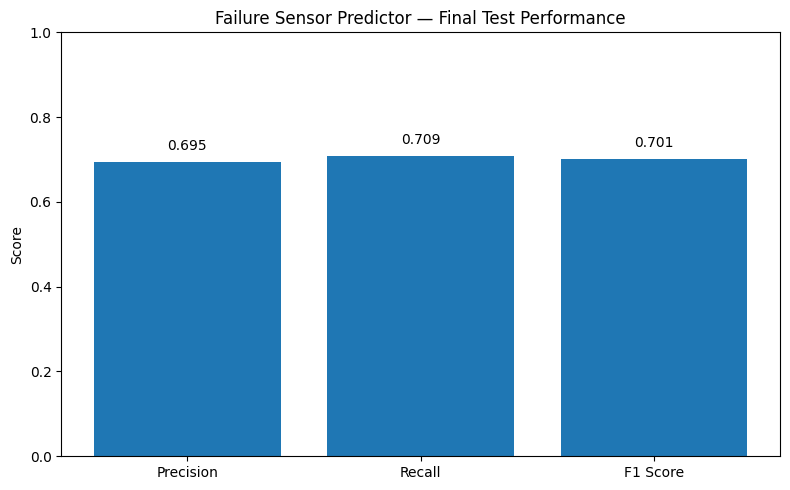

In [ ]:
# ============================================================
# QUALITY PASS 8 — FINAL PERFORMANCE SUMMARY
# ============================================================

final_metrics = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        test_precision,
        test_recall,
        f1_score(
            y_test,
            y_test_pred,
            zero_division=0
        )
    ]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    final_metrics["Metric"],
    final_metrics["Score"]
)

plt.ylim(0, 1)

plt.title(
    "Failure Sensor Predictor — Final Test Performance"
)

plt.ylabel("Score")

for bar, value in zip(
    bars,
    final_metrics["Score"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

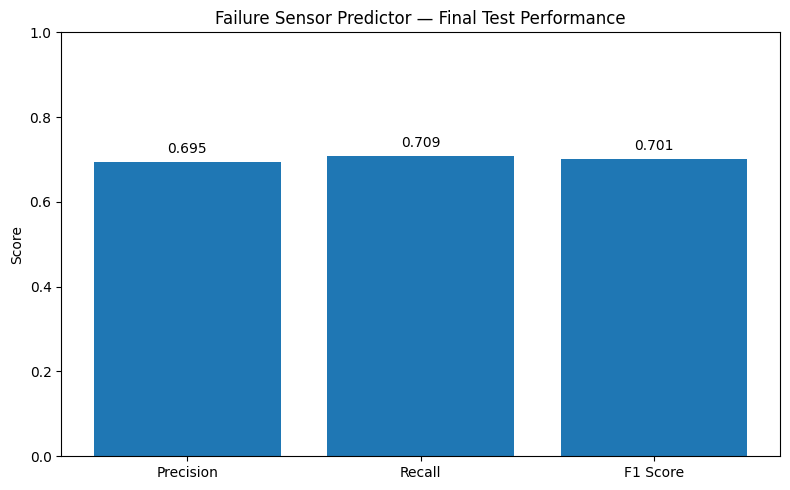

Saved:
/content/failure_sensor_model/figures/final_model_performance.png


In [ ]:
# ============================================================
# QUALITY PASS 9 — SAVE PERFORMANCE FIGURE
# ============================================================

performance_figure_path = os.path.join(
    FIGURE_DIR,
    "final_model_performance.png"
)

plt.figure(figsize=(8, 5))

plt.bar(
    final_metrics["Metric"],
    final_metrics["Score"]
)

plt.ylim(0, 1)

plt.title(
    "Failure Sensor Predictor — Final Test Performance"
)

plt.ylabel("Score")

for i, value in enumerate(
    final_metrics["Score"]
):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    performance_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(performance_figure_path)

In [ ]:
# ============================================================
# CREATING REUSABLE INFERENCE SCRIPT
# ============================================================

inference_code = '''
import joblib
import numpy as np
import pandas as pd


def create_rolling_features(
    df,
    feature_columns,
    window=12
):
    result = df.copy()

    result = result.sort_values(
        ["unit", "cycle"]
    ).reset_index(drop=True)

    for feature in feature_columns:

        grouped = result.groupby("unit")[feature]

        result[f"{feature}_rolling_mean"] = (
            grouped
            .rolling(window, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        result[f"{feature}_rolling_std"] = (
            grouped
            .rolling(window, min_periods=2)
            .std()
            .reset_index(level=0, drop=True)
            .fillna(0)
        )

        result[f"{feature}_diff"] = (
            grouped.diff().fillna(0)
        )

    return result


def load_model(model_path):
    """
    Load the trained failure prediction package.
    """

    return joblib.load(model_path)


def predict_failure_risk(
    new_sensor_data,
    model_package
):
    """
    Predict approaching failure risk.

    Parameters
    ----------
    new_sensor_data : pandas.DataFrame
        C-MAPSS-style telemetry.

    model_package : dict
        Saved model package.

    Returns
    -------
    pandas.DataFrame
        Failure probabilities and predictions.
    """

    model = model_package["model"]
    scaler = model_package["scaler"]
    feature_columns = model_package["feature_columns"]
    model_features = model_package["model_features"]
    rolling_window = model_package["rolling_window"]

    processed = create_rolling_features(
        new_sensor_data,
        model_features,
        rolling_window
    )

    processed = processed.replace(
        [np.inf, -np.inf],
        np.nan
    )

    processed = processed.dropna()

    X_new = processed[feature_columns]

    X_new_scaled = scaler.transform(X_new)

    probabilities = model.predict_proba(
        X_new_scaled
    )[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    results = processed[
        ["unit", "cycle"]
    ].copy()

    results["failure_probability"] = probabilities

    results["failure_prediction"] = predictions

    return results
'''

SRC_DIR = os.path.join(
    PROJECT_ROOT,
    "src"
)

os.makedirs(
    SRC_DIR,
    exist_ok=True
)

inference_path = os.path.join(
    SRC_DIR,
    "inference.py"
)

with open(
    inference_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(inference_code)

print("Created:")
print(inference_path)

Created:
/content/AIML_8_FailureSensorPredictor_byte/src/inference.py


In [ ]:
# Create a ZIP of the complete Task 8 project

import shutil

zip_path = shutil.make_archive(
    "/content/AIML-8-Failure-Sensor-Predictor",
    "zip",
    PROJECT_ROOT
)

print("ZIP created:")
print(zip_path)

ZIP created:
/content/AIML-8-Failure-Sensor-Predictor.zip


In [ ]:
# ============================================================
# CHECK COMPLETE PROJECT CONTENTS
# ============================================================

import os

for root, dirs, files in os.walk(PROJECT_ROOT):
    relative = os.path.relpath(root, PROJECT_ROOT)

    print(f"\n📁 {relative}")

    for file in files:
        path = os.path.join(root, file)
        size_kb = os.path.getsize(path) / 1024
        print(f"   📄 {file} ({size_kb:.1f} KB)")


📁 .
   📄 README.md (1.8 KB)
   📄 requirements.txt (0.1 KB)
   📄 .gitignore (0.1 KB)

📁 notebooks

📁 outputs

📁 outputs/figures
   📄 early_warning_timeline.png (133.1 KB)

📁 outputs/predictions
   📄 FD001_test_predictions.csv (324.0 KB)

📁 data

📁 src
   📄 inference.py (2.2 KB)

📁 reports
   📄 final_evaluation_report.json (0.5 KB)

📁 models
   📄 failure_sensor_predictor_package.joblib (10058.3 KB)
